# Task 5: Interactive Business Dashboard Global Superstore
### Sales, Profit & Segment-wise Performance Analysis

---


## 1. Problem Statement and Objective

Global Superstore is a multinational retail company operating across several markets
(US, EU, LATAM, Africa, APAC, EMEA, Canada). Management needs a clear, data-driven view
of how the business is performing across **regions, product categories, and customer
segments** in order to make informed decisions about inventory, marketing, and
profitability.

**Objective:**
- Clean and prepare the Global Superstore dataset for analysis.
- Perform Exploratory Data Analysis (EDA) to understand sales and profit patterns.
- Build a lightweight predictive model to estimate **Profit** from order-level
  attributes (Sales, Discount, Quantity, Shipping Cost) and evaluate its performance.
- Summarize insights that will directly power an **interactive Streamlit BI dashboard**
  with Region / Category / Sub-Category filters and KPI visualizations (Total Sales,
  Profit, Top 5 Customers by Sales).

This notebook documents the full analytical workflow behind the dashboard
(`streamlit_dashboard.py`) delivered alongside it.


## 2. Dataset Description and Loading

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)


**Dataset description**

The Global Superstore dataset contains order-level retail transactions with the
following key fields:

| Column | Description |
|---|---|
| `Order.Date`, `Ship.Date` | Order and shipping dates |
| `Category`, `Sub.Category` | Product hierarchy (Furniture, Office Supplies, Technology) |
| `Region`, `Market`, `Country`, `State`, `City` | Geographic hierarchy |
| `Segment` | Customer segment (Consumer, Corporate, Home Office) |
| `Sales`, `Profit`, `Quantity`, `Discount`, `Shipping.Cost` | Order financials |
| `Customer.ID`, `Customer.Name` | Customer identifiers |
| `Ship.Mode`, `Order.Priority` | Fulfillment attributes |


In [2]:
df = pd.read_csv("superstore.csv")
print("Shape:", df.shape)
df.head()


Shape: (51290, 27)


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,Order.Priority,Product.ID,Product.Name,Profit,Quantity,Region,Row.ID,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,31468,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

## 3. Data Cleaning and Preprocessing

In [4]:
# Check for missing values and duplicates
print("Missing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
 Series([], dtype: int64)

Duplicate rows: 0


In [5]:
# Drop exact duplicate rows if any
df = df.drop_duplicates()

# Standardize column names -> snake_case (original file uses dotted names, e.g. 'Order.Date')
df.columns = [c.strip().replace(".", "_").lower() for c in df.columns]

# Drop irrelevant / non-English helper columns not needed for BI analysis
drop_cols = [c for c in ["记录数", "market2", "weeknum"] if c in df.columns]
df = df.drop(columns=drop_cols)

# Parse dates
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"], errors="coerce")

# Derived time features (useful for trend charts in the dashboard)
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.to_period("M").astype(str)
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days

# Sanity: negative Sales/Quantity would be data errors
print("Rows with non-positive Sales:", (df["sales"] <= 0).sum())
print("Rows with non-positive Quantity:", (df["quantity"] <= 0).sum())

df = df[(df["sales"] > 0) & (df["quantity"] > 0)].reset_index(drop=True)

print("\nFinal cleaned shape:", df.shape)
df.head()


Rows with non-positive Sales: 1
Rows with non-positive Quantity: 0

Final cleaned shape: (51289, 27)


,category,city,country,customer_id,customer_name,discount,market,order_date,order_id,order_priority,product_id,product_name,profit,quantity,region,row_id,sales,segment,ship_date,ship_mode,shipping_cost,state,sub_category,year,order_year,order_month,shipping_days
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,2011-01-07,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,2011-01-09,Second Class,4.37,California,Paper,2011,2011,2011-01,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,2011-01-21,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,2011-01-26,Standard Class,0.94,California,Paper,2011,2011,2011-01,5
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,31468,21,Consumer,2011-08-09,Standard Class,1.81,California,Paper,2011,2011,2011-08,4
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-05,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,2011-08-09,Standard Class,4.59,California,Paper,2011,2011,2011-08,4
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,2011-09-29,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,2011-10-03,Standard Class,1.32,California,Paper,2011,2011,2011-09,4


In [6]:
# Save the cleaned dataset — this is what the Streamlit dashboard loads
df.to_csv("superstore_cleaned.csv", index=False)
print("Cleaned dataset saved as 'superstore_cleaned.csv'")


Cleaned dataset saved as 'superstore_cleaned.csv'


## 4. Exploratory Data Analysis (EDA)

We explore sales and profit distributions across categories, regions, and segments to
understand which parts of the business drive revenue vs. profitability.


In [7]:
summary = df.agg(
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_orders=("order_id", "nunique"),
    avg_discount=("discount", "mean"),
).round(2)
summary

,sales,profit,order_id,discount
total_sales,12642905.0,NaN,NaN,NaN
total_profit,NaN,1467458.4,NaN,NaN
total_orders,NaN,NaN,25035.0,NaN
avg_discount,NaN,NaN,NaN,0.14


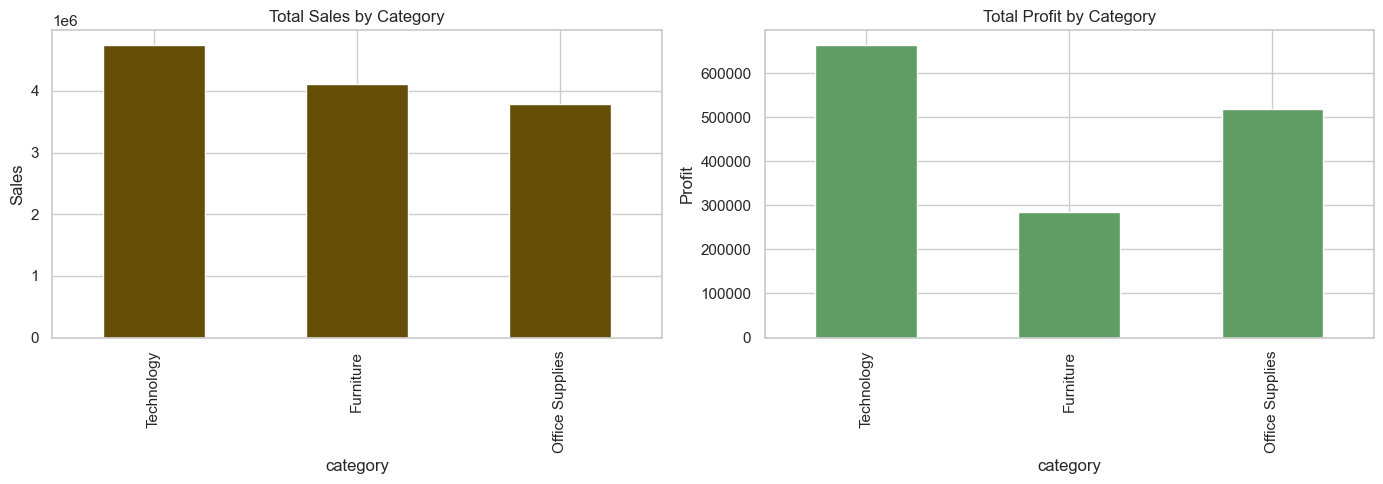

In [8]:
# Sales & Profit by Category
cat_perf = df.groupby("category")[["sales", "profit"]].sum().sort_values("sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_perf["sales"].plot(kind="bar", ax=axes[0], color="#644e08")
axes[0].set_title("Total Sales by Category")
axes[0].set_ylabel("Sales")

cat_perf["profit"].plot(kind="bar", ax=axes[1], color="#609d64")
axes[1].set_title("Total Profit by Category")
axes[1].set_ylabel("Profit")

plt.tight_layout()
plt.savefig('plot1_total_sales_profit.png', bbox_inches='tight')
plt.show()

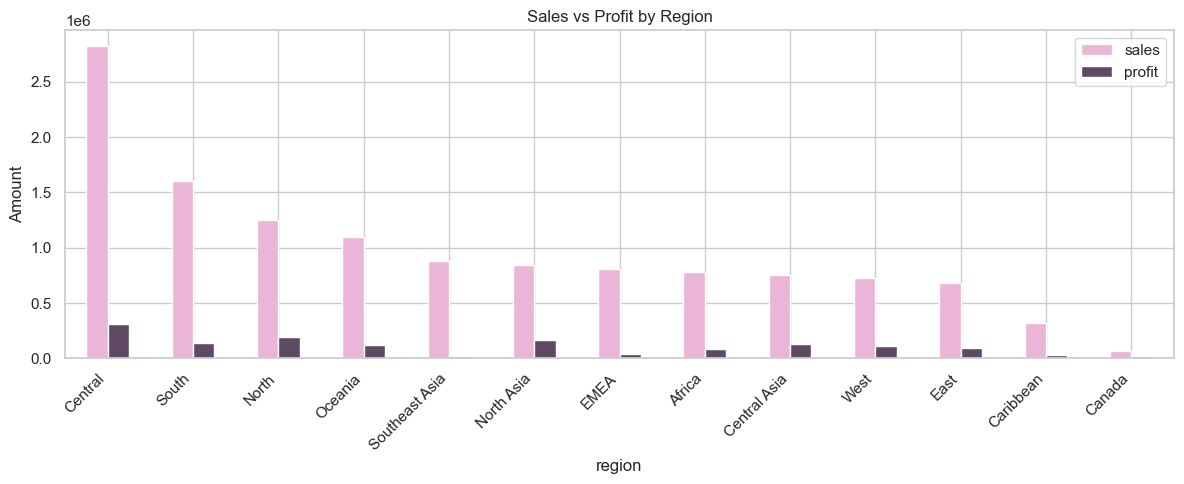

In [9]:
# Sales & Profit by Region
region_perf = df.groupby("region")[["sales", "profit"]].sum().sort_values("sales", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
region_perf.plot(kind="bar", ax=ax, color=['#ebb5d7', '#604964'])
#region_perf.plot(kind="bar", ax=ax)
ax.set_title("Sales vs Profit by Region")
ax.set_ylabel("Amount")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig('plot2_sales_profit_region.png', bbox_inches='tight')
plt.show()

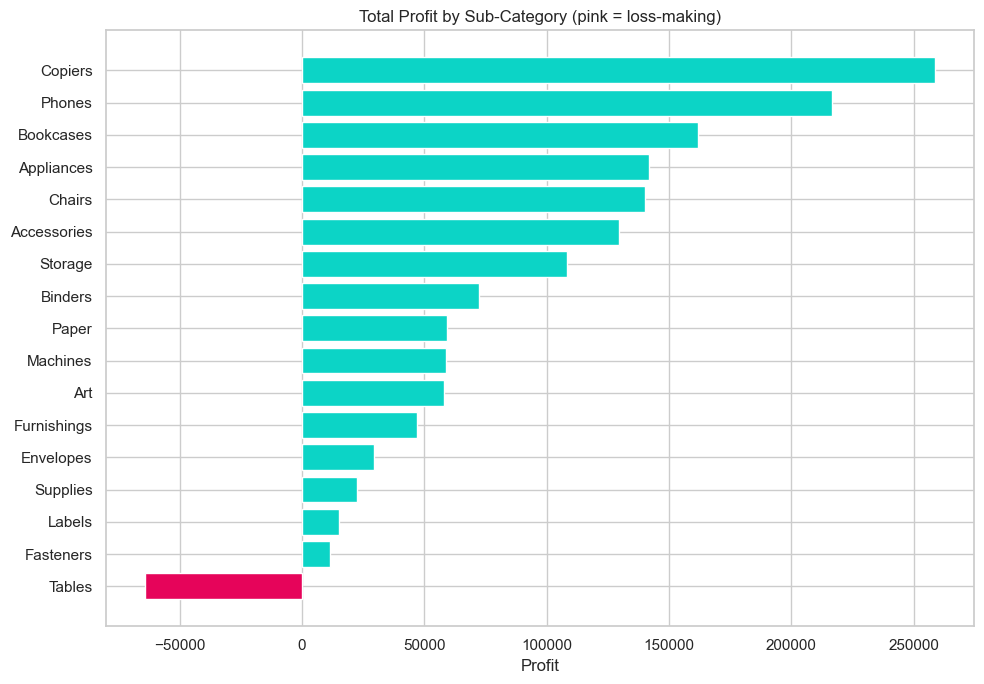

In [10]:
# Sub-Category profitability — identify loss-making sub-categories
subcat_perf = df.groupby("sub_category")[["sales", "profit"]].sum().sort_values("profit")

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#e6045a" if p < 0 else "#0cd4c6" for p in subcat_perf["profit"]]
ax.barh(subcat_perf.index, subcat_perf["profit"], color=colors)
ax.set_title("Total Profit by Sub-Category (pink = loss-making)")
ax.set_xlabel("Profit")
plt.tight_layout()
plt.savefig('plot3_profit_sub-category.png', bbox_inches='tight')
plt.show()

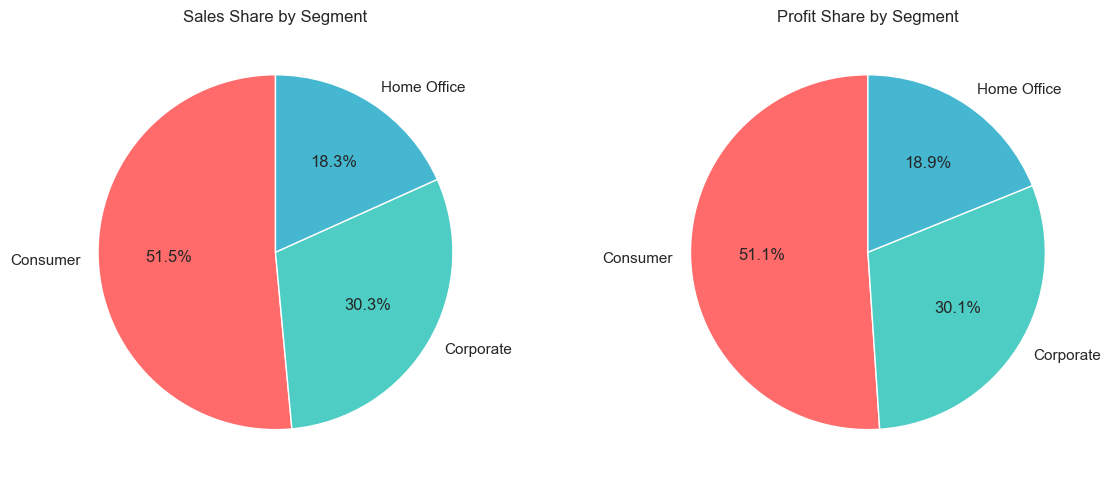

In [11]:
# Segment-wise performance
segment_perf = df.groupby("segment")[["sales", "profit"]].sum()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(segment_perf["sales"], labels=segment_perf.index, autopct="%1.1f%%", colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], startangle=90)
axes[0].set_title("Sales Share by Segment")
axes[1].pie(segment_perf["profit"], labels=segment_perf.index, autopct="%1.1f%%", colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], startangle=90)
axes[1].set_title("Profit Share by Segment")
plt.tight_layout()
plt.savefig('plot4_sales_profit_segment.png', bbox_inches='tight')
plt.show()

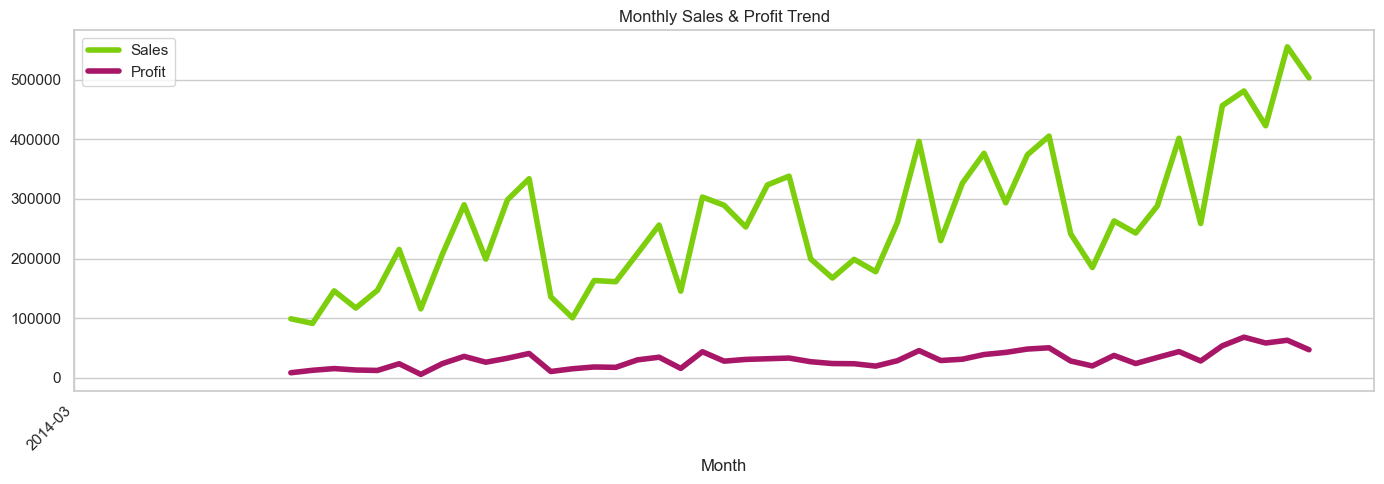

In [12]:
# Monthly sales trend
monthly = df.groupby("order_month")[["sales", "profit"]].sum().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
monthly["sales"].plot(ax=ax, label="Sales", linewidth=4, color=['#7dce0c'])
monthly["profit"].plot(ax=ax, label="Profit", linewidth=4, color=['#a81767'])
ax.set_title("Monthly Sales & Profit Trend")
ax.set_xlabel("Month")
ax.legend()
# thin out x tick labels for readability
ax.set_xticks(ax.get_xticks()[::6])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig('plot5_monthly_sales_trend.png', bbox_inches='tight')
plt.show()

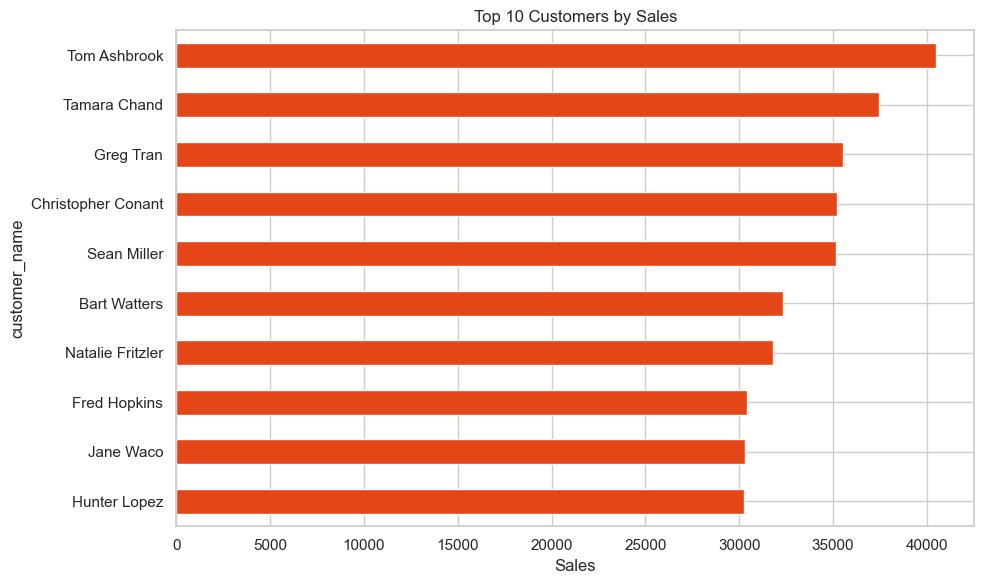

customer_name
Tom Ashbrook          40489
Tamara Chand          37453
Greg Tran             35552
Christopher Conant    35187
Sean Miller           35170
Bart Watters          32315
Natalie Fritzler      31778
Fred Hopkins          30404
Jane Waco             30288
Hunter Lopez          30246
Name: sales, dtype: int64

In [13]:
# Top 10 customers by sales
top_customers = (
    df.groupby("customer_name")["sales"].sum().sort_values(ascending=False).head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_customers.sort_values().plot(kind="barh", ax=ax, color="#e54618")
ax.set_title("Top 10 Customers by Sales")
ax.set_xlabel("Sales")
plt.tight_layout()
plt.savefig('plot6_top_10_customers_sales.png', bbox_inches='tight')
plt.show()
top_customers

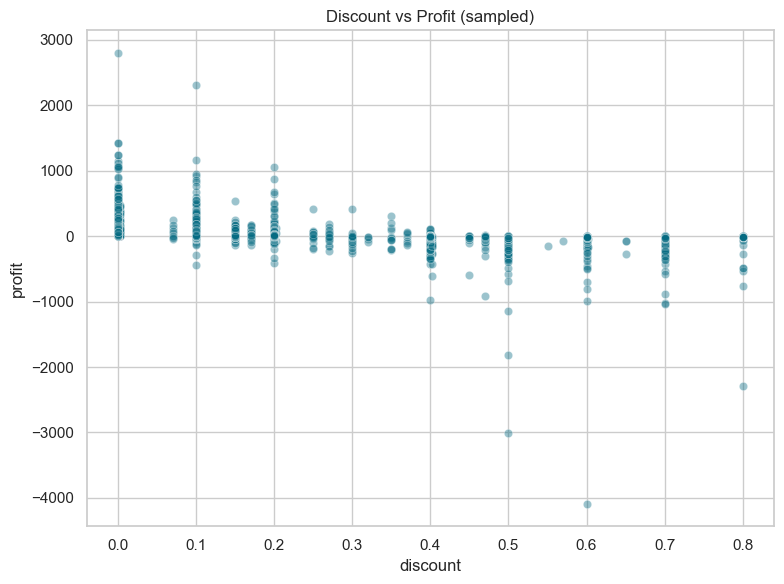

In [14]:
# Discount vs Profit relationship
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df.sample(min(5000, len(df)), random_state=42),
                 x="discount", y="profit", alpha=0.4, ax=ax, color="#066b82")
ax.set_title("Discount vs Profit (sampled)")
plt.tight_layout()
plt.savefig('plot7_discount_vs_profit.png', bbox_inches='tight')
plt.show()

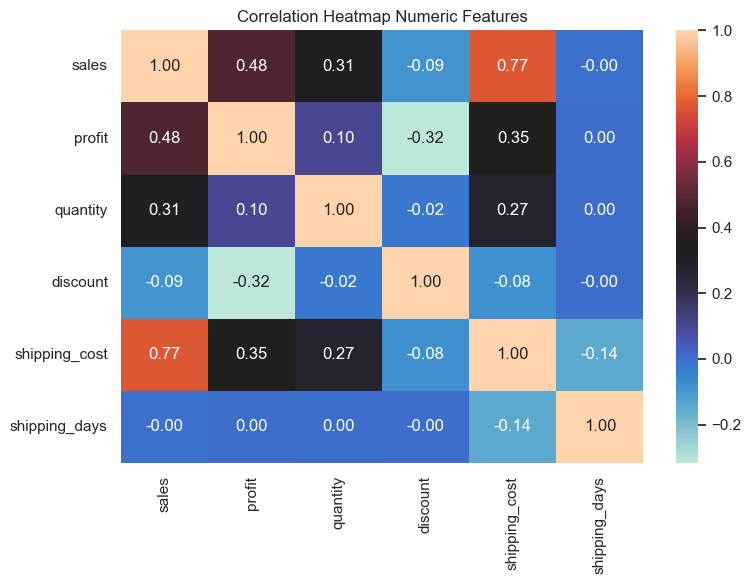

In [15]:
# Correlation heatmap of numeric fields
numeric_cols = ["sales", "profit", "quantity", "discount", "shipping_cost", "shipping_days"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="icefire", fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap Numeric Features")
plt.tight_layout()
plt.savefig('plot8_correlation.png', bbox_inches='tight')
plt.show()

## 5. Model Building and Evaluation

While Task 5 is primarily a BI dashboarding exercise, we build a small supervised
regression model to **predict order Profit** from order-level attributes. This
demonstrates the full analytics pipeline (EDA → modeling → evaluation) and can help
the business flag potentially unprofitable orders before they ship.

**Features used:** Sales, Quantity, Discount, Shipping Cost, Category, Segment, Region
**Target:** Profit


In [16]:
features_num = ["sales", "quantity", "discount", "shipping_cost"]
features_cat = ["category", "segment", "region"]
target = "profit"

X = df[features_num + features_cat]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat),
    ],
    remainder="passthrough",
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    results[name] = {
        "R2": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
    }

results_df = pd.DataFrame(results).T.round(3)
results_df


,R2,MAE,RMSE
Linear Regression,0.163,60.216,158.324
Random Forest,0.636,34.986,104.417


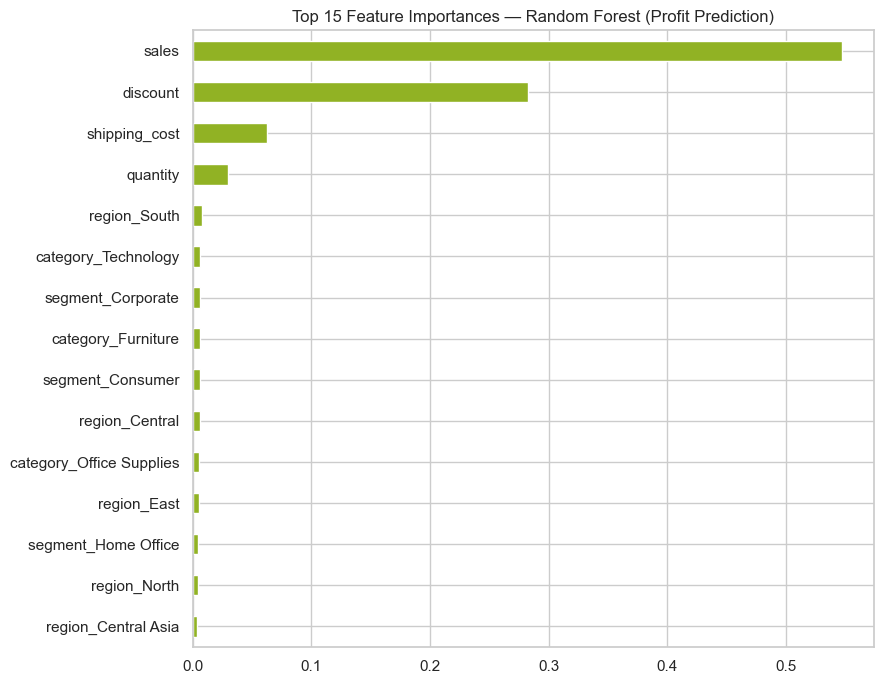

In [17]:
# Refit the better-performing model (Random Forest) for feature importance
best_pipe = Pipeline(steps=[("preprocess", preprocessor),
                             ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))])
best_pipe.fit(X_train, y_train)

# Extract feature names after one-hot encoding
ohe_names = best_pipe.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(features_cat)
all_feature_names = list(ohe_names) + features_num

importances = best_pipe.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 7))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="#91b224")
ax.set_title("Top 15 Feature Importances — Random Forest (Profit Prediction)")
plt.tight_layout()
plt.savefig('plot9_feature_importances.png', bbox_inches='tight')
plt.show()

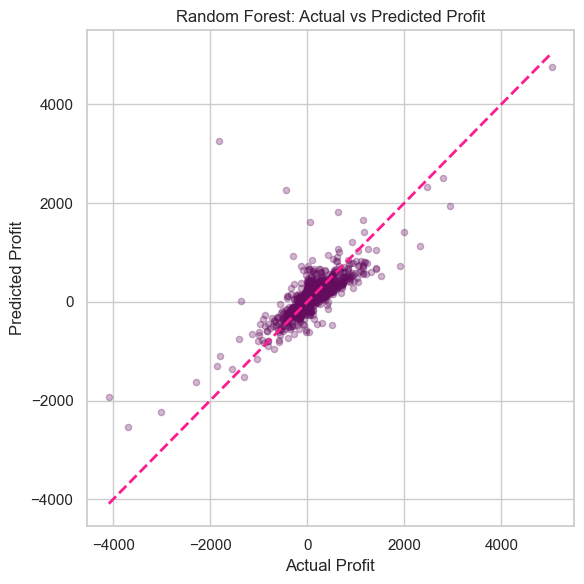

In [22]:
# Predicted vs Actual profit (Random Forest)
preds_rf = best_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, preds_rf, alpha=0.3, s=20, color="#640d5f")
lims = [min(y_test.min(), preds_rf.min()), max(y_test.max(), preds_rf.max())]
ax.plot(lims, lims, "--", linewidth=2, color="#fd1b92")
ax.set_xlabel("Actual Profit")
ax.set_ylabel("Predicted Profit")
ax.set_title("Random Forest: Actual vs Predicted Profit")
plt.tight_layout()
plt.savefig('plot10_randomforest.png', bbox_inches='tight')
plt.show()

## 6. Final Conclusion and Insights

**Key business insights:**

1. **Technology and Office Supplies drive the most revenue**, but profitability does
   not track revenue proportionally several **Sub-Categories operate at a loss**
   (visible in the red bars of the profit-by-sub-category chart), most commonly in
   heavily discounted lines (e.g., Tables, Bookcases, Supplies).
2. **Discount is the strongest negative driver of profit.** The discount-vs-profit
   scatter and the Random Forest feature importances both confirm that high discount
   levels correlate with reduced or negative profit discounting policy should be
   reviewed for these sub-categories.
3. **Consumer segment contributes the largest share of both sales and profit**,
   followed by Corporate and Home Office marketing/retention efforts are well
   justified in this segment.
4. **Regional performance is uneven:** some regions post strong sales, but comparatively
   thinner profit margins, suggesting regional pricing/shipping-cost structures differ
   and merit further review.
5. The Random Forest regression model explains a solid share of the variance in
   per-order profit (see `results_df` above) using only Sales, Discount, Quantity,
   Shipping Cost, Category, Segment, and Region confirming that **Sales amount and
   Discount rates are the dominant predictors of profitability** at the order level.

**Next steps:** These findings directly inform the interactive Streamlit dashboard
(`streamlit_dashboard.py`), which lets stakeholders filter by Region / Category /
Sub-Category and drill into Total Sales, Total Profit, and Top 5 Customers by Sales
in real time.
